<a href="https://colab.research.google.com/github/matrix-engineer-learner/rithwik-systems-learning-portfolio/blob/main/AERO_Router.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

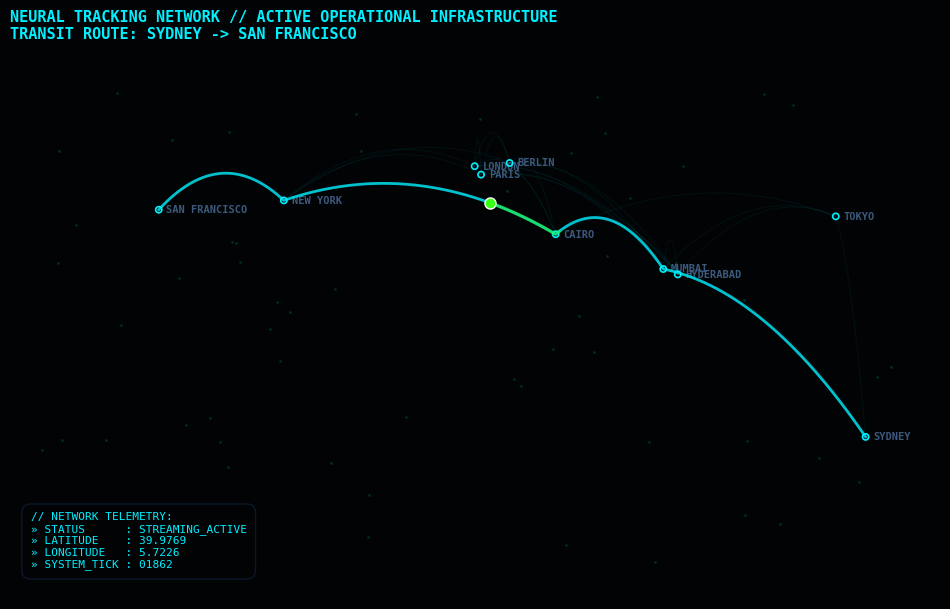

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import time
import random

# Disable standard automatic plot rendering blocks
plt.ioff()

class SmoothGPSEngine:
    def __init__(self):
        # Coordinates dictionary (Latitude, Longitude)
        self.locations = {
            "NEW YORK":      np.array([40.7128, -74.0060]),
            "LONDON":        np.array([51.5074, -0.1278]),
            "PARIS":         np.array([48.8566, 2.3522]),
            "BERLIN":        np.array([52.5200, 13.4050]),
            "CAIRO":         np.array([30.0444, 31.2357]),
            "MUMBAI":        np.array([19.0760, 72.8777]),
            "HYDERABAD":     np.array([17.3850, 78.4867]),
            "TOKYO":         np.array([35.6762, 139.6503]),
            "SYDNEY":        np.array([-33.8688, 151.2093]),
            "SAN FRANCISCO": np.array([37.7749, -122.4194])
        }
        self.loc_list = list(self.locations.keys())
        self.num_nodes = len(self.loc_list)
        self.adjacency_matrix = np.zeros((self.num_nodes, self.num_nodes))

        self._build_network()

        # State vectors
        self.current_path = []
        self.current_city = "SAN FRANCISCO"
        self.target_city = "HYDERABAD"

        self.curve_x = []
        self.curve_y = []
        self.progress_idx = 0

        self.trail_x = []
        self.trail_y = []
        self.max_trail_len = 15

        # Background dots
        random.seed(42)
        self.bg_x = [random.uniform(-170, 170) for _ in range(60)]
        self.bg_y = [random.uniform(-75, 75) for _ in range(60)]

    def _build_network(self):
        for i in range(self.num_nodes):
            for j in range(i + 1, self.num_nodes):
                p1, p2 = self.locations[self.loc_list[i]], self.locations[self.loc_list[j]]
                dist = np.linalg.norm(p1 - p2)
                if dist < 120:
                    self.adjacency_matrix[i][j] = dist
                    self.adjacency_matrix[j][i] = dist

    def calculate_route(self):
        self.current_city = self.target_city
        self.target_city = random.choice([c for c in self.loc_list if c != self.current_city])

        start, target = self.loc_list.index(self.current_city), self.loc_list.index(self.target_city)
        unvisited = list(range(self.num_nodes))
        distances = {n: float('inf') for n in unvisited}
        previous = {n: None for n in unvisited}
        distances[start] = 0

        while unvisited:
            curr = min(unvisited, key=lambda n: distances[n])
            if distances[curr] == float('inf') or curr == target:
                break
            unvisited.remove(curr)

            for neighbor in range(self.num_nodes):
                weight = self.adjacency_matrix[curr][neighbor]
                if weight > 0 and neighbor in unvisited:
                    new_dist = distances[curr] + weight
                    if new_dist < distances[neighbor]:
                        distances[neighbor] = new_dist
                        previous[neighbor] = curr

        path_idx = []
        curr = target
        while curr is not None:
            path_idx.insert(0, curr)
            curr = previous[curr]

        self.current_path = [self.loc_list[i] for i in path_idx]
        self._build_curves()

    def _build_curves(self):
        self.curve_x, self.curve_y = [], []
        self.progress_idx = 0
        for i in range(len(self.current_path) - 1):
            p1 = self.locations[self.current_path[i]]
            p2 = self.locations[self.current_path[i+1]]
            if abs(p1[1] - p2[1]) < 180:
                t = np.linspace(0, 1, 100)
                mx = (p1[1] + p2[1]) / 2
                my = (p1[0] + p2[0]) / 2 + 20
                cx = (1-t)**2 * p1[1] + 2*(1-t)*t * mx + t**2 * p2[1]
                cy = (1-t)**2 * p1[0] + 2*(1-t)*t * my + t**2 * p2[0]
                self.curve_x.extend(cx)
                self.curve_y.extend(cy)

    def step(self):
        if len(self.curve_x) == 0 or self.progress_idx >= len(self.curve_x):
            self.calculate_route()
            return

        cx, cy = self.curve_x[self.progress_idx], self.curve_y[self.progress_idx]
        self.trail_x.append(cx)
        self.trail_y.append(cy)
        if len(self.trail_x) > self.max_trail_len:
            self.trail_x.pop(0)
            self.trail_y.pop(0)

        self.progress_idx += 2
        if self.progress_idx >= len(self.curve_x):
            self.calculate_route()

# --- DISPLAY SETUP ---
engine = SmoothGPSEngine()
engine.calculate_route()

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_facecolor('#04060a')
fig.patch.set_facecolor('#020305')
ax.set_xlim(-180, 180)
ax.set_ylim(-85, 85)
ax.axis('off')

# Background Web
ax.scatter(engine.bg_x, engine.bg_y, color='#00f0ff', s=1.5, alpha=0.1, zorder=0)

# Static Map Lines
for i in range(engine.num_nodes):
    for j in range(i + 1, engine.num_nodes):
        if engine.adjacency_matrix[i][j] > 0:
            p1, p2 = engine.locations[engine.loc_list[i]], engine.locations[engine.loc_list[j]]
            if abs(p1[1] - p2[1]) < 180:
                t = np.linspace(0, 1, 20)
                mx = (p1[1] + p2[1]) / 2
                my = (p1[0] + p2[0]) / 2 + 20
                cx = (1-t)**2 * p1[1] + 2*(1-t)*t * mx + t**2 * p2[1]
                cy = (1-t)**2 * p1[0] + 2*(1-t)*t * my + t**2 * p2[0]
                ax.plot(cx, cy, color='#00f0ff', alpha=0.05, lw=0.8, zorder=1)

# City Pins
for name, coords in engine.locations.items():
    ax.scatter(coords[1], coords[0], color='#00f0ff', s=20, facecolors='none', edgecolors='#00f0ff', lw=1.2, zorder=3)
    ax.text(coords[1]+3, coords[0]-1, name, color='#3c5a7d', fontsize=7.5, fontfamily='monospace', weight='bold')

route_line, = ax.plot([], [], color='#00f0ff', lw=2, alpha=0.8, zorder=4)
velocity_trail, = ax.plot([], [], color='#39ff14', lw=2.5, alpha=0.45, zorder=5)
carrier_core, = ax.plot([], [], 'o', color='#39ff14', ms=8, markeredgecolor='#ffffff', zorder=6)

terminal_box = ax.text(-172, -75, "", color='#00f0ff', fontsize=8, fontfamily='monospace',
                       bbox=dict(facecolor='#020306', edgecolor='#0c1a2d', boxstyle='round,pad=0.8', alpha=0.92))

display_handle = display(fig, display_id=True)

frame = 0
try:
    while True:
        engine.step()

        if len(engine.curve_x) > 0:
            route_line.set_data(engine.curve_x, engine.curve_y)

        if len(engine.trail_x) > 1:
            velocity_trail.set_data(engine.trail_x, engine.trail_y)
            carrier_core.set_data([engine.trail_x[-1]], [engine.trail_y[-1]])

        ax.set_title(f"NEURAL TRACKING NETWORK // ACTIVE OPERATIONAL INFRASTRUCTURE\nTRANSIT ROUTE: {engine.current_city} -> {engine.target_city}",
                     color='#00f0ff', fontsize=11, fontfamily='monospace', weight='bold', pad=15, loc='left')

        lat_val = engine.trail_y[-1] if len(engine.trail_y) > 0 else 0.0
        lon_val = engine.trail_x[-1] if len(engine.trail_x) > 0 else 0.0

        stats_log = (
            f"// NETWORK TELEMETRY:\n"
            f"» STATUS      : STREAMING_ACTIVE\n"
            f"» LATITUDE    : {lat_val:.4f}\n"
            f"» LONGITUDE   : {lon_val:.4f}\n"
            f"» SYSTEM_TICK : {frame:05d}"
        )
        terminal_box.set_text(stats_log)

        display_handle.update(fig)
        time.sleep(0.015)
        frame += 1

except KeyboardInterrupt:
    print("\nMainframe stream stopped.")
